<a href="https://colab.research.google.com/github/keerthanarbsc24-debug/Deep_learning/blob/main/Vehicle_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Keerthana R

USN  : 1RUA24SCS0048

## Convolutional Neural Network for Vehicle Image Classification

## Introduction

This project uses a Convolutional Neural Network (CNN) to classify vehicle images into four categories: Bus, Car, Truck, and Motorcycle.

The CNN learns important visual features from the images and uses these features to predict the vehicle category.


## Importing Required Libraries

The required Python libraries are imported for image processing, CNN model building, visualization, dataset splitting, and model evaluation.

- TensorFlow is used to build and train the CNN.
- NumPy is used for numerical operations.
- Matplotlib and Seaborn are used for visualization.
- Scikit-learn is used for splitting the dataset and evaluating the model.

In [ ]:
import os
import zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import layers, models

## Dataset Upload

The vehicle image dataset is uploaded as a ZIP file and extracted for processing.

The dataset contains four vehicle categories:
- Bus
- Car
- Truck
- Motorcycle

In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

zip_path = "/content/archive.zip"
extract_path = "/content/vehicle_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
dataset_path = "/content/vehicle_dataset/Dataset"

classes = ["Bus", "Car", "Truck", "motorcycle"]

print("Classes:", classes)

Classes: ['Bus', 'Car', 'Truck', 'motorcycle']


##Load and Preprocess Images


In [ ]:
IMG_SIZE = 128

images = []
labels = []

for label, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        try:
            image = tf.keras.utils.load_img(
                image_path,
                target_size=(IMG_SIZE, IMG_SIZE)
            )

            image = tf.keras.utils.img_to_array(image)

            images.append(image)
            labels.append(label)

        except:
            print("Could not load:", image_path)

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Images shape: (400, 128, 128, 3)
Labels shape: (400,)


## Reshaping Images

In [ ]:
images = images.reshape(-1, 128, 128, 3)

print("Reshaped images:", images.shape)

Reshaped images: (400, 128, 128, 3)


##Class Distribution

In [ ]:
for i, class_name in enumerate(classes):
    print(class_name, ":", np.sum(labels == i))

Bus : 100
Car : 100
Truck : 100
motorcycle : 100


##Visualize Sample Images

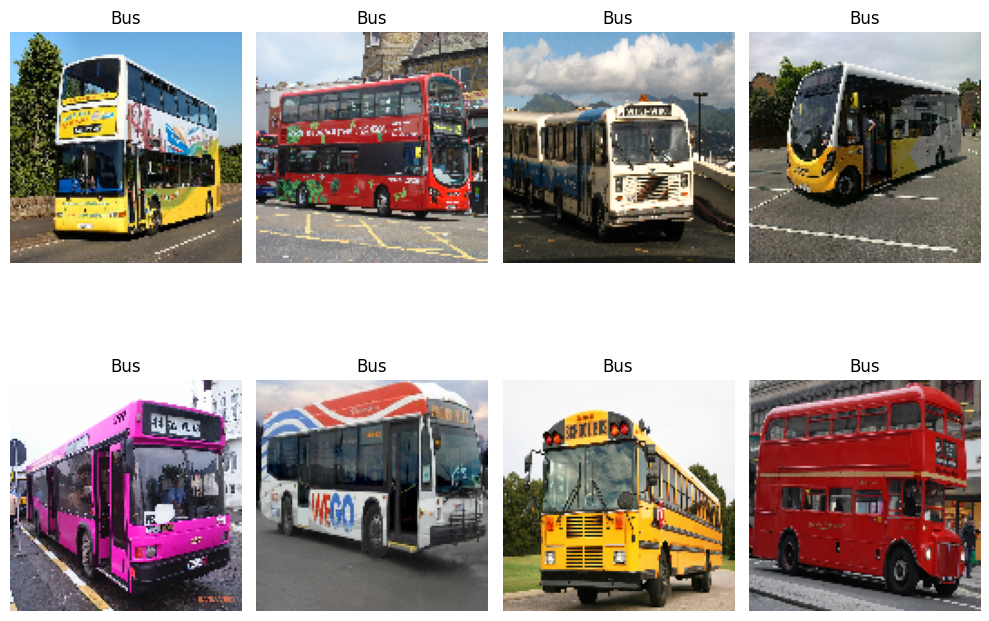

In [ ]:
plt.figure(figsize=(10, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i].astype("uint8"))
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Image Normalization

In [ ]:
images = images / 255.0

# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (320, 128, 128, 3)
Testing images: (80, 128, 128, 3)


## CNN Architecture

A Convolutional Neural Network (CNN) is used for vehicle image classification.

The model consists of three convolutional layers with 32, 64, and 128 filters respectively. A 3 × 3 kernel and ReLU activation function are used in the convolutional layers.

Max pooling with a pool size of 2 × 2 is applied after each convolution layer to reduce the spatial dimensions of the feature maps.

The extracted features are then flattened and passed to a fully connected Dense layer containing 128 neurons. Dropout with a rate of 0.5 is used to reduce overfitting.

The final Dense layer contains four neurons with Softmax activation to classify the images into Bus, Car, Truck, and Motorcycle.

In [ ]:
model = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    ),

    # Pooling Layer 1
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Pooling Layer 2
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    # Pooling Layer 3
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(
        4,
        activation="softmax"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##CNN Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation and Training

The CNN model is compiled using the Adam optimizer with a learning rate of 0.001.

Sparse categorical cross-entropy is used as the loss function because the vehicle images belong to four different classes.

The model is trained for 20 epochs with a batch size of 32. A validation split of 20% is used to monitor the model's performance during training.

The training history is stored in the `history` variable, which is later used to plot training and validation accuracy and loss.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9453 - loss: 0.2235 - val_accuracy: 0.6250 - val_loss: 1.4944
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9727 - loss: 0.1322 - val_accuracy: 0.6875 - val_loss: 1.2198
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 892ms/step - accuracy: 0.9883 - loss: 0.0701 - val_accuracy: 0.7031 - val_loss: 1.5281
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 914ms/step - accuracy: 0.9766 - loss: 0.0791 - val_accuracy: 0.6406 - val_loss: 1.5483
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9922 - loss: 0.0346 - val_accuracy: 0.6719 - val_loss: 1.6624
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 894ms/step - accuracy: 0.9922 - loss: 0.0411 - val_accuracy: 0.7031 - val_loss: 1.5809
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 902ms/step - accuracy: 0.9844 - loss: 0.0316 - val_accuracy: 0.6094 - val_loss: 1.7603
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9922 - loss: 0.0337 - val_accuracy: 0.6562 - val_loss: 1.6849


# Training and Validation Accuracy

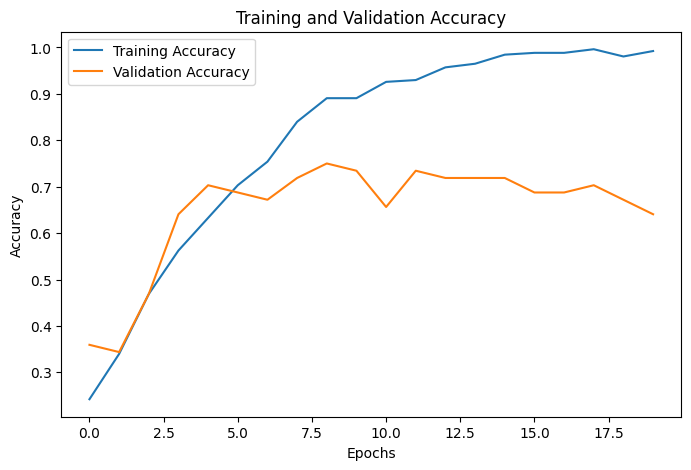

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

# Training and Validation Loss

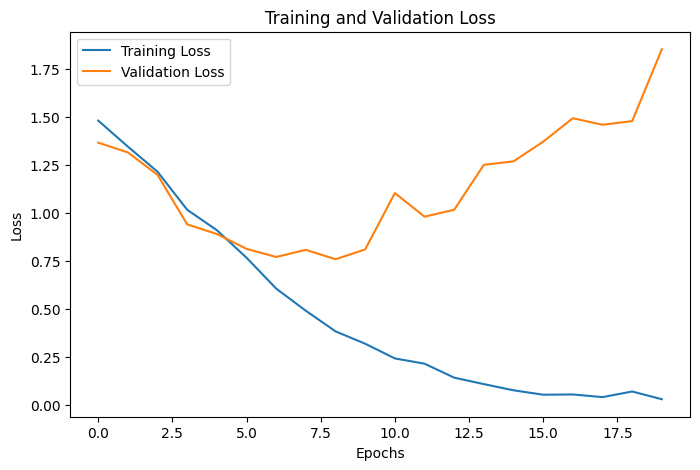

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

## Model Evaluation

The trained CNN model is evaluated using the test dataset.

The performance of the model is measured using test accuracy and test loss. A confusion matrix is used to identify correct and incorrect predictions for each vehicle class.

A classification report is also generated to obtain precision, recall, F1-score, and support for each class.

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.5500 - loss: 2.1023
Test Loss: 2.1023316383361816
Test Accuracy: 0.550000011920929


## Model Predictions

In [ ]:
predictions = model.predict(X_test)

y_pred = np.argmax(
    predictions,
    axis=1
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 361ms/step


## Confusion Matrix

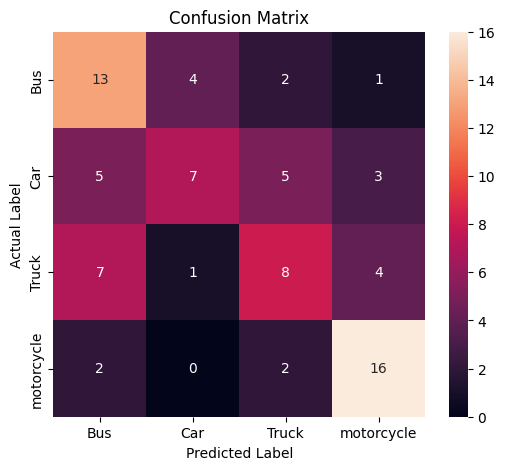

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

## Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

         Bus       0.48      0.65      0.55        20
         Car       0.58      0.35      0.44        20
       Truck       0.47      0.40      0.43        20
  motorcycle       0.67      0.80      0.73        20

    accuracy                           0.55        80
   macro avg       0.55      0.55      0.54        80
weighted avg       0.55      0.55      0.54        80



## Actual vs Predicted Images

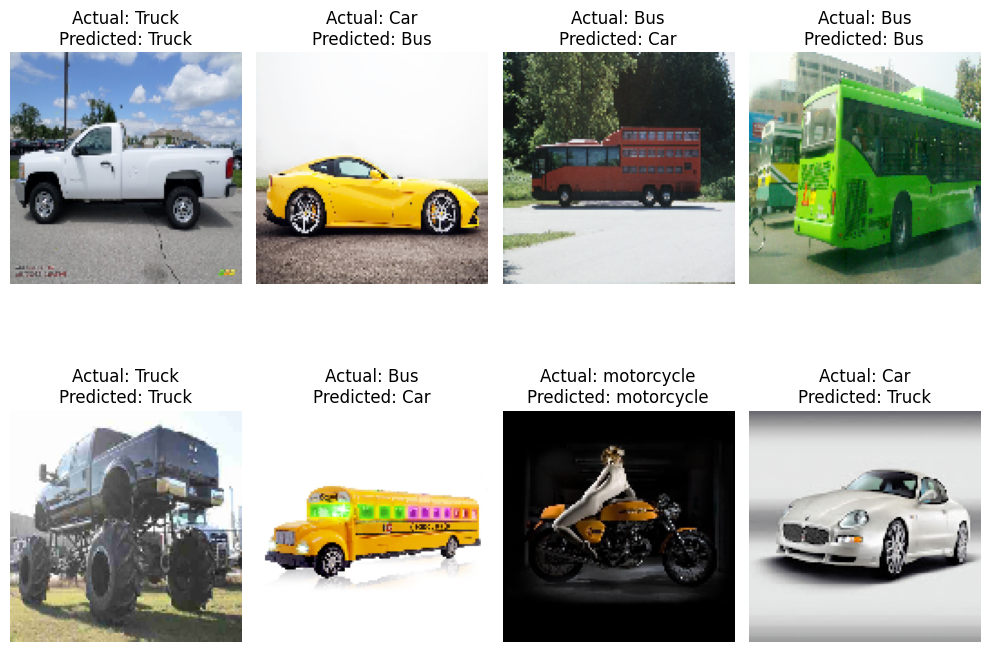

In [ ]:
plt.figure(figsize=(10, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(X_test[i])

    predicted_class = classes[y_pred[i]]
    actual_class = classes[y_test[i]]

    plt.title(
        "Actual: " + actual_class +
        "\nPredicted: " + predicted_class
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Hyperparameter Analysis

The performance of a CNN model depends on several hyperparameters that are selected before training. These parameters control the architecture and the training process of the model.

The important hyperparameters considered in this project are:

| Hyperparameter | Value Used | Effect on Model |
|---|---:|---|
| Number of Filters | 32, 64, 128 | More filters allow the model to learn more features, but increase computation. |
| Kernel Size | 3 × 3 | Helps detect local features such as edges, textures, and shapes. |
| Pooling Size | 2 × 2 | Reduces the spatial dimensions of feature maps while retaining important information. |
| Activation Function | ReLU | Introduces non-linearity and helps the network learn complex patterns. |
| Learning Rate | 0.001 | Controls how quickly the model updates its weights during training. |
| Batch Size | 32 | Determines the number of images processed before updating the model. |
| Number of Epochs | 20 | Determines how many times the model learns from the complete training dataset. |
| Dropout | 0.5 | Helps reduce overfitting by randomly ignoring some neurons during training. |

### Effect of Changing Hyperparameters

Increasing the number of filters can help the CNN learn more complex features, but it also increases computational cost.

A larger kernel can examine a larger region of the image, while a smaller kernel such as 3 × 3 focuses on local features.

Changing the pooling size affects the amount of spatial information retained after pooling.

The learning rate controls the speed of learning. A very high learning rate may make training unstable, while a very low learning rate may make training slower.

Increasing the number of epochs can improve learning, but training for too long may cause overfitting.

Dropout helps the model generalize better by reducing its dependence on particular neurons.

## Conclusion

A Convolutional Neural Network was successfully developed to classify vehicle images into four categories: Bus, Car, Truck, and Motorcycle.

The images were resized, normalized, and divided into training and testing datasets. The CNN model uses convolutional layers with different filters, ReLU activation, max pooling, a fully connected Dense layer, and Softmax activation for classification.

The model was trained and evaluated using accuracy and loss. A confusion matrix and classification report were used to understand the classification performance of each vehicle category.

The hyperparameter analysis shows that parameters such as filters, kernel size, pooling size, learning rate, batch size, epochs, and dropout can affect the learning process, accuracy, computational cost, and generalization of the CNN model.

Overall, the CNN provides an effective approach for automatic vehicle image classification.